# Model creation

author: @Embra-Schuilenburg

COMP 432: Main Project

This document will define functions, classes, and scripts for the models that will be used later in this project. Models that will be created include:

- 1D single-task CNNs
- 1D multi-task CNNs
- ? feature extractor setup

For each model this notebook will:
- Define the basic structure of the model if a (sufficient prexisting implementation doesn't exist)
- Define any needed training, validation, or direct solution methods
- Implement performance monitoring, optimization, and hyperparameter tuning methods (although no optimization or tuning will be performed in this notebook)

Models will be constructed as general models with specifiable parameters that can be adjusted by experiment. Referring to the model as 'general' is to say that numerous data embedding strategies may be experimented with; as finding the ideal fMRI encoding is a very important factor in the success of any model used on it. As such, models should be able to process any data of a similar modality even if it's dimensions aren't identical.

## Imports and packages

In [2]:
import copy
from helper_functions import load_saved_run
import importnb
import pprint
import matplotlib.pyplot as plt
import numpy as np
import os
from pathlib import Path
import random
import sklearn as sk
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import wandb

In [3]:
# Set seeds for reproducability of tests

def set_seed(seed=67):
    # Python
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)

    # NumPy
    np.random.seed(seed)

    # PyTorch
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # Deterministic behavior
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    # Stricter determinism
    torch.use_deterministic_algorithms(True)


SEED = 67
set_seed(SEED)

---

# 1D single-task CNNs

**Overview**
In this section the report will outline and then construct the framework for a general single signal predicting 1D CNNs that will be used later in this project. 

**I/O details**
Expected inputs: one run of ROIs averaged over a window for each sequnce (*see figure below*)
Input shape: num_rois, seq_len (100, 60)
Target shape: 1, seq_len (1, 60) vector of scalers

**Hyperparameters**:
- Input channels = 1
- Output channnels = 1
- Kernel size = 100x3
- Padding = one zero on each end
- Stride length = 0

Expected inputs:
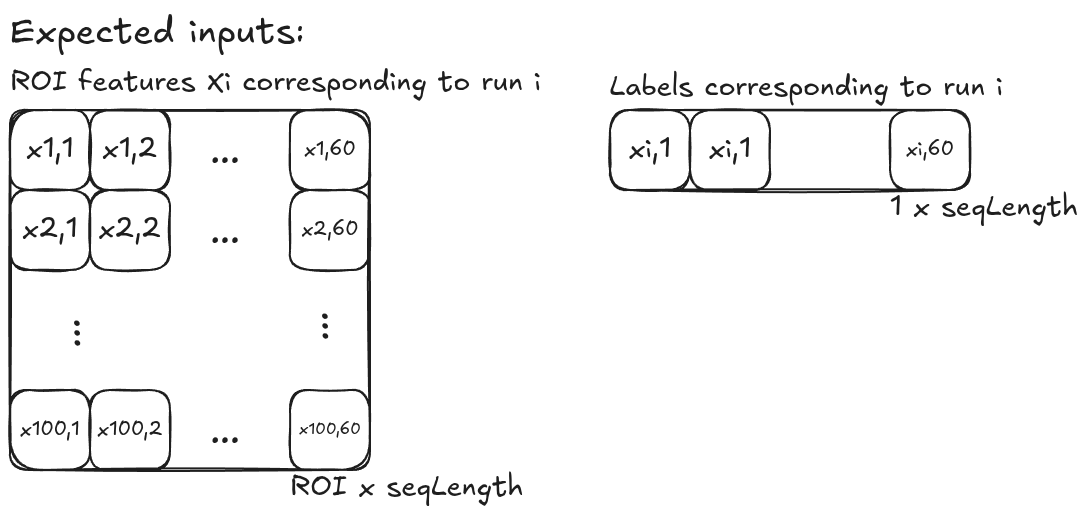

## Data loading, splitting, and normalization functions

Runs will be collected from the processed-data folder as was specified in `1-data-preprocessing.ipynb`. 

Please note two important fact regarding the data:

1. It is essential that although a run is considered a single input, splitting is performed by participant. This is essential because should inputs be split by row, there would be the possibility of data leakage in which the model is evaluated on data from a participant it was trained on. 
2. Normalization of features and of signal labels is not required as they have been normalized already. ROI features were normalized during preprocessing, and label values were normalized during data collection.
    - No global normalization was performed, ROIs were normalized within each run and labels were normalized by subject


In [4]:
# Data collection method

def collect_run_records(output_dir):
    """
    Find all saved run-level npz files and return records.

    Expected structure:
        output_dir/
            sub-01/
                run-1/
                    features_and_labels.npz
                    trial_metadata.csv
    """
    output_dir = Path(output_dir)
    npz_paths = sorted(output_dir.glob('sub-*/run-*/features_and_labels.npz'))

    if len(npz_paths) == 0:
        raise FileNotFoundError(f'No run files found under: {output_dir}')

    records = []
    for npz_path in npz_paths:
        subject_id = npz_path.parent.parent.name
        run_id = npz_path.parent.name

        records.append({
            'subject_id': subject_id,
            'run_id': run_id,
            'npz_path': npz_path
        })

    return records


# Data splitting method

def split_records_by_subject(records, train_frac=0.70, val_frac=0.15, test_frac=0.15, seed=67, return_subjects=False):
    """
    Split at the subject level to avoid leakage. 
    Splits should be passed as decimals between 0.0 and 1.0 and should sum to 1.
    All runs from a subject stay in exactly one split.
    """
    subjects = sorted({rec['subject_id'] for rec in records})
    n_subjects = len(subjects)
    rng = np.random.default_rng(seed)
    rng.shuffle(subjects)

    n_test = max(1, int(round(test_frac * n_subjects)))
    n_val = max(1, int(round(val_frac * n_subjects)))
    n_train = n_subjects - n_val - n_test

    train_subjects = set(subjects[:n_train])
    val_subjects = set(subjects[n_train:n_train + n_val])
    test_subjects = set(subjects[n_train + n_val:])

    train_records = [r for r in records if r['subject_id'] in train_subjects]
    val_records = [r for r in records if r['subject_id'] in val_subjects]
    test_records = [r for r in records if r['subject_id'] in test_subjects]

    if return_subjects:
        return train_records, val_records, test_records, np.array(train_subjects), np.array(val_subjects), np.array(test_subjects)
    else:
        return train_records, val_records, test_records


# Data set

class RunSequenceDataset(Dataset):
    """
    One item = one run.

    Returns:
        x       : [n_trials, n_rois]
        y       : [n_trials]       (single-task target sequence)
        length  : int
    """

    def __init__(self, records, target_name='surprise'):
        self.records = records
        self.target_name = target_name

        if target_name not in {'surprise', 'V'}:
            raise ValueError('target_name must be "surprise" or "V"')

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        rec = self.records[idx]
        X, _, y_surprise, y_V, roi_names, y_names = load_saved_run(
            rec['npz_path'])

        X = X.astype(np.float32)

        if self.target_name == 'surprise':
            y = y_surprise.astype(np.float32)
        else:
            y = y_V.astype(np.float32)

        # TODO: update graphic to match dataloader instance dimensions (transpose)
        item = {
            'x': torch.from_numpy(X),   # [n_trials, n_rois]
            'y': torch.from_numpy(y)   # [n_trials]
        }

        return item

## Single-task 1D CNN

This CNN class will define the model that will be single task prediction. The model will be a sequence-to-sequence model and convole over the trials. For each trial, a predicted RL signal will be output. 

In [ ]:
# TODO: plan where hyperparameter tuning should be placed
# TODO: maybe add W&B hyperparameter tracking to later tuning
# Single-task CNN class

class SingleTask1DCNN(nn.Module):
    """
    CNN for single-task regression on run sequences.

    Input:
        x: [B, T, R]
            B = batch size
            T = number of trials
            R = number of ROIs

    Output:
        y_pred: [B, T]
            One scalar prediction per trial
    """

    def __init__(
        self,
        n_rois,
        hidden_channels=32,
        kernel_size=3,
        dropout=.1
    ):
        super().__init__()

        if kernel_size % 2 == 0:
            raise ValueError(
                "kernel_size should be odd so same-length padding is simple.")

        padding = kernel_size // 2

        self.feature_extractor = nn.Sequential(
            nn.Conv1d(
                in_channels=n_rois,
                out_channels=hidden_channels,
                kernel_size=kernel_size,
                padding=padding
            ),
            nn.ReLU(),
            nn.Dropout(dropout),

            # nn.Conv1d(
            #     in_channels=hidden_channels,
            #     out_channels=hidden_channels,
            #     kernel_size=kernel_size,
            #     padding=padding
            # ),
            # nn.ReLU(),
            # nn.Dropout(dropout),
        )

        self.head = nn.Conv1d(
            in_channels=hidden_channels,
            out_channels=1,
            kernel_size=1
        )

    def forward(self, x):
        x = x.transpose(1, 2)      # [B, R, T]

        x = self.feature_extractor(x)

        x = self.head(x)           # [B, 1, T]
        x = x.squeeze(1)           # [B, T]
        return x

In [ ]:
# # Testing scratch-block

# batch = next(iter(train_loader))

# x = batch['x']   # [B, T, R]
# print("input shape:", x.shape)

# model = SingleTask1DCNN(
#     n_rois=x.shape[-1],
#     hidden_channels=32,
#     kernel_size=3
# )

# y_pred = model(x)
# print("output shape:", y_pred.shape)
# print("target shape:", batch['y'].shape)

## Training and eval functions

In [ ]:
# Training and test/val epochs

def train_epoch(model, dataloader, optimizer, criterion, device):
    """
    Run one training epoch and return mean batch loss.
    """
    model.train()
    total_loss = 0.0
    n_batches = 0

    for batch in dataloader:
        x = batch['x'].to(device)   # [B, T, R]
        y = batch['y'].to(device)   # [B, T]

        optimizer.zero_grad()

        y_pred = model(x)           # [B, T]
        loss = criterion(y_pred, y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        n_batches += 1

    mean_loss = total_loss / n_batches
    return mean_loss


def val_epoch(model, dataloader, criterion, device):
    """
    Run evaluation and return mean batch loss.
    """
    model.eval()
    total_loss = 0.0
    n_batches = 0

    with torch.no_grad():
        for batch in dataloader:
            x = batch['x'].to(device)   # [B, T, R]
            y = batch['y'].to(device)   # [B, T]

            y_pred = model(x)
            loss = criterion(y_pred, y)

            total_loss += loss.item()
            n_batches += 1

    mean_loss = total_loss / n_batches
    return mean_loss

In [ ]:
# TODO: consider adding an early stopping mechanism
# Model training loop

def train_model(model, train_loader, val_loader, optimizer, criterion, device, epochs=20):
    """
    Full training loop.
    Returns a history dictionary.
    """
    history = {
        'train_loss': [],
        'val_loss': []
    }

    for epoch in range(epochs):
        train_loss = train_epoch(
            model=model,
            dataloader=train_loader,
            optimizer=optimizer,
            criterion=criterion,
            device=device
        )

        val_loss = val_epoch(
            model=model,
            dataloader=val_loader,
            criterion=criterion,
            device=device
        )

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)

        print(
            f"Epoch {epoch + 1:02d}/{epochs:02d} | "
            f"train_loss={train_loss:.4f} | "
            f"val_loss={val_loss:.4f}"
        )

    return history

In [5]:
# Testing scratch-block

records = collect_run_records('processed_data/')
print(records)

train, val, test, train_subjects, val_subjects, test_subjects = split_records_by_subject(
    records=records, train_frac=.9, val_frac=.05, test_frac=.05, seed=SEED, return_subjects=True)

print(len(train),
      len(val),
      len(test),
      train_subjects,
      val_subjects,
      test_subjects
      )

[{'subject_id': 'sub-01', 'run_id': 'run-1', 'npz_path': PosixPath('processed_data/sub-01/run-1/features_and_labels.npz')}, {'subject_id': 'sub-01', 'run_id': 'run-2', 'npz_path': PosixPath('processed_data/sub-01/run-2/features_and_labels.npz')}, {'subject_id': 'sub-01', 'run_id': 'run-3', 'npz_path': PosixPath('processed_data/sub-01/run-3/features_and_labels.npz')}, {'subject_id': 'sub-01', 'run_id': 'run-4', 'npz_path': PosixPath('processed_data/sub-01/run-4/features_and_labels.npz')}, {'subject_id': 'sub-01', 'run_id': 'run-5', 'npz_path': PosixPath('processed_data/sub-01/run-5/features_and_labels.npz')}, {'subject_id': 'sub-01', 'run_id': 'run-6', 'npz_path': PosixPath('processed_data/sub-01/run-6/features_and_labels.npz')}, {'subject_id': 'sub-02', 'run_id': 'run-1', 'npz_path': PosixPath('processed_data/sub-02/run-1/features_and_labels.npz')}, {'subject_id': 'sub-02', 'run_id': 'run-2', 'npz_path': PosixPath('processed_data/sub-02/run-2/features_and_labels.npz')}, {'subject_id': 

In [ ]:
target = 'V'

batch_size = 16

train_dataset = RunSequenceDataset(
    train,
    target_name=target
)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_dataset = RunSequenceDataset(
    val,
    target_name=target
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

test_dataset = RunSequenceDataset(
    test,
    target_name=target
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

In [ ]:
# Testing scratch-block

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

sample_batch = next(iter(train_loader))
n_rois = sample_batch['x'].shape[-1]

model = SingleTask1DCNN(
    n_rois=n_rois,
    hidden_channels=2,
    kernel_size=3,
    dropout=.4
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

epochs = 100

history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    criterion=criterion,
    device=device,
    epochs=epochs
)

test_loss = val_epoch(
    model=model,
    dataloader=test_loader,
    criterion=criterion,
    device=device
)

print(f"Test loss: {test_loss:.4f}")

In [ ]:
def zero_baseline_mse(dataloader):
    total = 0.0
    n_batches = 0

    for batch in dataloader:
        y = batch['y']
        y_pred = torch.zeros_like(y)
        loss = nn.functional.mse_loss(y_pred, y)
        total += loss.item()
        n_batches += 1

    return total / n_batches


print("Zero baseline train:", zero_baseline_mse(train_loader))
print("Zero baseline val:", zero_baseline_mse(val_loader))
print("Zero baseline test:", zero_baseline_mse(test_loader))

In [ ]:
train_loss = np.array(history['train_loss'])
plt.figure()
plt.plot(range(1, epochs+1), train_loss)
plt.figure()
plt.plot(range(1, epochs+1), history['val_loss'])

## Testing

# 1D multi-task CNNs

In [ ]:
class RunSequenceDataset(Dataset):
    """
    One item = one run.

    Returns:
        x       : [n_trials, n_rois]
        y       : [n_trials, 2]   (multitask targets: surprise, V)
        length  : int
    """

    def __init__(self, records):
        self.records = records

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        rec = self.records[idx]
        X, y_joint, y_surprise, y_V, roi_names, y_names = load_saved_run(
            rec['npz_path'])

        X = X.astype(np.float32)
        y = y_joint.astype(np.float32)

        return {
            'x': torch.from_numpy(X),   # [T, R]
            'y': torch.from_numpy(y),   # [T, 2]
            'length': X.shape[0],
        }

## Multi-task CNN

In [ ]:
class MultiTask1DCNN(nn.Module):
    """
    Shared temporal CNN with one head per task.

    Input:
        x: [B, T, R]

    Output:
        out: {
            'surprise': [B, T],
            'V': [B, T]
        }
    """

    def __init__(self, n_rois, hidden_channels=32, kernel_size=3, dropout=.1):
        super().__init__()

        if kernel_size % 2 == 0:
            raise ValueError("kernel_size should be odd.")

        self.n_rois = n_rois
        padding = kernel_size // 2

        self.conv1 = nn.Conv1d(
            in_channels=n_rois,
            out_channels=hidden_channels,
            kernel_size=kernel_size,
            padding=padding
        )
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)

        self.head_surprise = nn.Conv1d(hidden_channels, 1, kernel_size=1)
        self.head_V = nn.Conv1d(hidden_channels, 1, kernel_size=1)

    def forward(self, x):
        # x: [B, T, R]
        if x.ndim != 3:
            raise ValueError(f"Expected [B, T, R], got {x.shape}")
        if x.shape[-1] != self.n_rois:
            raise ValueError(f"Expected {self.n_rois} ROIs, got {x.shape[-1]}")

        x = x.transpose(1, 2).contiguous()   # [B, R, T]

        h = self.conv1(x)
        h = self.relu(h)

        y_surprise = self.head_surprise(h).squeeze(1)   # [B, T]
        y_V = self.head_V(h).squeeze(1)                 # [B, T]

        return {
            'surprise': y_surprise,
            'V': y_V
        }

## Training and eval functions

In [ ]:
# Training and validation/test epochs

def train_epoch(model, dataloader, optimizer, criterion, device, w_surprise=1.0, w_V=1.0):
    model.train()

    total_loss_sum = 0.0
    surprise_loss_sum = 0.0
    V_loss_sum = 0.0
    n_batches = 0

    for batch in dataloader:
        x = batch['x'].to(device)   # [B, T, R]
        y = batch['y'].to(device)   # [B, T, 2]

        optimizer.zero_grad()

        outputs = model(x)
        loss, loss_surprise, loss_V = multitask_loss_fn(
            outputs=outputs,
            y_true=y,
            criterion=criterion,
            w_surprise=w_surprise,
            w_V=w_V
        )

        loss.backward()
        optimizer.step()

        total_loss_sum += loss.item()
        surprise_loss_sum += loss_surprise.item()
        V_loss_sum += loss_V.item()
        n_batches += 1

    return {
        'loss': total_loss_sum / n_batches,
        'loss_surprise': surprise_loss_sum / n_batches,
        'loss_V': V_loss_sum / n_batches
    }


def val_epoch(model, dataloader, criterion, device, w_surprise=1.0, w_V=1.0):
    model.eval()

    total_loss_sum = 0.0
    surprise_loss_sum = 0.0
    V_loss_sum = 0.0
    n_batches = 0

    with torch.no_grad():
        for batch in dataloader:
            x = batch['x'].to(device)
            y = batch['y'].to(device)

            outputs = model(x)
            loss, loss_surprise, loss_V = multitask_loss_fn(
                outputs=outputs,
                y_true=y,
                criterion=criterion,
                w_surprise=w_surprise,
                w_V=w_V
            )

            total_loss_sum += loss.item()
            surprise_loss_sum += loss_surprise.item()
            V_loss_sum += loss_V.item()
            n_batches += 1

    return {
        'loss': total_loss_sum / n_batches,
        'loss_surprise': surprise_loss_sum / n_batches,
        'loss_V': V_loss_sum / n_batches
    }

In [ ]:
# TODO: consider adding an early stopping mechanism
# Model training loop

def multitask_loss_fn(outputs, y_true, criterion, w_surprise=1.0, w_V=1.0):
    if y_true.ndim != 3 or y_true.shape[-1] != 2:
        raise ValueError(
            f"Expected y_true shape [B, T, 2], got {tuple(y_true.shape)}")

    y_surprise = y_true[:, :, 0]
    y_V = y_true[:, :, 1]

    loss_surprise = criterion(outputs['surprise'], y_surprise)
    loss_V = criterion(outputs['V'], y_V)

    weighted_sum = w_surprise * loss_surprise + w_V * loss_V
    weight_total = w_surprise + w_V
    mean_loss = weighted_sum / weight_total

    return mean_loss, loss_surprise, loss_V


def train_model(
    model,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    device,
    epochs=20,
    w_surprise=1.0,
    w_V=1.0
):
    history = {
        'train_loss': [],
        'train_loss_surprise': [],
        'train_loss_V': [],
        'val_loss': [],
        'val_loss_surprise': [],
        'val_loss_V': []
    }

    best_val_loss = float('inf')
    best_state = copy.deepcopy(model.state_dict())

    for epoch in range(epochs):
        train_metrics = train_epoch(
            model=model,
            dataloader=train_loader,
            optimizer=optimizer,
            criterion=criterion,
            device=device,
            w_surprise=w_surprise,
            w_V=w_V
        )

        val_metrics = val_epoch(
            model=model,
            dataloader=val_loader,
            criterion=criterion,
            device=device,
            w_surprise=w_surprise,
            w_V=w_V
        )

        history['train_loss'].append(train_metrics['loss'])
        history['train_loss_surprise'].append(train_metrics['loss_surprise'])
        history['train_loss_V'].append(train_metrics['loss_V'])

        history['val_loss'].append(val_metrics['loss'])
        history['val_loss_surprise'].append(val_metrics['loss_surprise'])
        history['val_loss_V'].append(val_metrics['loss_V'])

        if val_metrics['loss'] < best_val_loss and epoch > 3:
            best_val_loss = val_metrics['loss']
            best_state = copy.deepcopy(model.state_dict())

        wandb.log({
            'epoch': epoch + 1,
            'train_loss': train_metrics['loss'],
            'train_loss_surprise': train_metrics['loss_surprise'],
            'train_loss_V': train_metrics['loss_V'],
            'val_loss': val_metrics['loss'],
            'val_loss_surprise': val_metrics['loss_surprise'],
            'val_loss_V': val_metrics['loss_V'],
        })

        print(
            f"Epoch {epoch + 1:02d}/{epochs:02d} | "
            f"train_total={train_metrics['loss']:.4f} | "
            f"train_surprise={train_metrics['loss_surprise']:.4f} | "
            f"train_V={train_metrics['loss_V']:.4f} | "
            f"val_total={val_metrics['loss']:.4f} | "
            f"val_surprise={val_metrics['loss_surprise']:.4f} | "
            f"val_V={val_metrics['loss_V']:.4f}"
        )

    model.load_state_dict(best_state)
    return history, best_val_loss


def run_sweep_train():
    with wandb.init():
        config = wandb.config

        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

        # Datasets
        train_dataset = RunSequenceDataset(train)
        val_dataset = RunSequenceDataset(val)

        # DataLoaders: batch_size comes from sweep
        train_loader = DataLoader(
            train_dataset,
            batch_size=config.batch_size,
            shuffle=True,
            num_workers=0
        )

        val_loader = DataLoader(
            val_dataset,
            batch_size=config.batch_size,
            shuffle=False,
            num_workers=0
        )

        # Infer n_rois from one sample
        sample = train_dataset[0]
        n_rois = sample['x'].shape[-1]

        model = MultiTask1DCNN(
            n_rois=n_rois,
            hidden_channels=config.hidden_channels,
            kernel_size=config.kernel_size,
            dropout=config.dropout
        ).to(device)

        optimizer = torch.optim.Adam(model.parameters(), lr=config.lr)
        criterion = nn.MSELoss()

        history, best_val_loss = train_model(
            model=model,
            train_loader=train_loader,
            val_loader=val_loader,
            optimizer=optimizer,
            criterion=criterion,
            device=device,
            epochs=100
        )

        # Explicit final log for sweep metric
        wandb.log({'best_val_loss': best_val_loss, 'val_loss': best_val_loss})

In [ ]:
sweep_config = {
    'method': 'bayes',
    'metric': {
        'name': 'val_loss',
        'goal': 'minimize'
    },
    'parameters': {
        'dropout': {
            'values': [0.3, 0.4, 0.5]
        },
        'hidden_channels': {
            'values': [2, 4, 6, 8, 16]
        },
        'kernel_size': {
            'values': [3, 5, 7]
        },
        'batch_size': {
            'values': [1, 4, 8, 16]
        },
        'lr': {
            'values': [1e-3, 5e-3, 1e-2]
        }
    }
}

pprint.pprint(sweep_config)

In [ ]:
sweep_id = wandb.sweep(sweep_config, project='multitask-1dcnn-runs')
wandb.agent(sweep_id, function=run_sweep_train)

In [ ]:
# Testing scratch-block


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

sample_batch = next(iter(train_loader))
n_rois = sample_batch['x'].shape[-1]

model = MultiTask1DCNN(
    n_rois=n_rois,
    hidden_channels=3,
    kernel_size=3,
    dropout=.1
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

epochs = 100

history = train_model(
    model,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    device,
    epochs=epochs
)

test_metrics = val_epoch(
    model=model,
    dataloader=test_loader,
    criterion=criterion,
    device=device,
    w_surprise=1.0,
    w_V=1.0
)

print(
    f"Test total={test_metrics['loss']:.4f} | "
    f"Test surprise={test_metrics['loss_surprise']:.4f} | "
    f"Test V={test_metrics['loss_V']:.4f}"
)

In [ ]:
train_loss = np.array(history['train_loss'])
train_surpise = np.array(history['train_loss_surprise'])
train_V = np.array(history['train_loss_V'])

val_loss = np.array(history['val_loss'])
val_surpise = np.array(history['val_loss_surprise'])
val_V = np.array(history['val_loss_V'])

x = range(1, epochs+1)

plt.figure()
plt.plot(x, train_loss, label='Train loss')
plt.plot(x, train_surpise, label='Train loss, surprise')
plt.plot(x, train_V, label='Train loss, V')
plt.legend()

plt.figure()
plt.plot(x, val_loss, label='Val loss')
plt.plot(x, val_surpise, label='Val loss, surprise')
plt.plot(x, val_V, label='Val loss, V')
plt.legend()

# Single-task linear models

In [6]:
# Dataset extraction

X_train_list = []
y_V_train_list = []
y_surprise_train_list = []
X_val_list = []
y_V_val_list = []
y_surprise_val_list = []
X_test_list = []
y_V_test_list = []
y_surprise_test_list = []


for rec in train:
    X_run, _, y_surprise, y_V, roi_names, y_names = load_saved_run(
        rec['npz_path'])
    X_train_list.append(X_run)
    y_V_train_list.append(y_V.reshape(-1, 1))
    y_surprise_train_list.append(y_surprise.reshape(-1, 1))

X_train = np.vstack(X_train_list)
y_V_train = np.vstack(y_V_train_list).ravel()
y_surprise_train = np.vstack(y_surprise_train_list).ravel()

for rec in val:
    X_run, _, y_surprise, y_V, roi_names, y_names = load_saved_run(
        rec['npz_path'])
    X_val_list.append(X_run)
    y_V_val_list.append(y_V.reshape(-1, 1))
    y_surprise_val_list.append(y_surprise.reshape(-1, 1))

X_val = np.vstack(X_val_list)
y_V_val = np.vstack(y_V_val_list).ravel()
y_surprise_val = np.vstack(y_surprise_val_list).ravel()

for rec in test:
    X_run, _, y_surprise, y_V, roi_names, y_names = load_saved_run(
        rec['npz_path'])
    X_test_list.append(X_run)
    y_V_test_list.append(y_V.reshape(-1, 1))
    y_surprise_test_list.append(y_surprise.reshape(-1, 1))

X_test = np.vstack(X_test_list)
y_V_test = np.vstack(y_V_test_list).ravel()
y_surprise_test = np.vstack(y_surprise_test_list).ravel()

print(X_train.shape, y_V_train.shape, y_surprise_train.shape)

(18720, 100) (18720,) (18720,)


In [ ]:
# Scale the data since normalization was previously performed at the run level for ROIs and subject level for labels

X_scaler = StandardScaler()
y_V_scaler = StandardScaler()
y_surprise_scaler = StandardScaler()

X_train = X_scaler.fit_transform(X_train)
X_val = X_scaler.transform(X_val)
X_test = X_scaler.transform(X_test)

y_V_train = y_V_scaler.fit_transform(y_V_train.reshape(-1, 1)).ravel()
y_V_val = y_V_scaler.transform(y_V_val.reshape(-1, 1)).ravel()
y_V_test = y_V_scaler.transform(y_V_test.reshape(-1, 1)).ravel()

y_surprise_train = y_surprise_scaler.fit_transform(
    y_surprise_train.reshape(-1, 1)
).ravel()
y_surprise_val = y_surprise_scaler.transform(
    y_surprise_val.reshape(-1, 1)
).ravel()
y_surprise_test = y_surprise_scaler.transform(
    y_surprise_test.reshape(-1, 1)
).ravel()

# Check that scaling worked
print("X_train_scaled mean (first 5 cols):", X_train.mean(axis=0)[:5])
print("X_train_scaled std  (first 5 cols):", X_train.std(axis=0)[:5])
print("y_V_train_scaled mean:", y_V_train.mean())
print("y_V_train_scaled std :", y_V_train.std())
print("y_surprise_train_scaled mean:", y_surprise_train.mean())
print("y_surprise_train_scaled std :", y_surprise_train.std())

### LASSO models

In [ ]:
# LASSO implementation and alpha tuning

alphas = np.logspace(-4, 1, 30)

best_alpha = None
best_val_mse = float("inf")
best_model = None

for alpha in alphas:
    model = sk.linear_model.Lasso(
        alpha=alpha, max_iter=1000000, random_state=SEED)
    model.fit(X_train, y_V_train)

    val_pred = model.predict(X_val)
    val_mse = mean_squared_error(y_V_val, val_pred)

    if val_mse < best_val_mse:
        best_val_mse = val_mse
        best_alpha = alpha
        best_model = model
        print(f"new best alpha={alpha:.5f}  val_mse={val_mse:.6f}")

print("Best alpha:", best_alpha)
print("Best val MSE:", best_val_mse)

test_pred = best_model.predict(X_test)
print("Test MSE:", mean_squared_error(y_V_test, test_pred))
print("Test R^2:", r2_score(y_V_test, test_pred))


best_alpha = None
best_val_mse = float("inf")
best_model = None

for alpha in alphas:
    model = sk.linear_model.Lasso(
        alpha=alpha, max_iter=1000000, random_state=SEED)
    model.fit(X_train, y_surprise_train)

    val_pred = model.predict(X_val)
    val_mse = mean_squared_error(y_surprise_val, val_pred)

    if val_mse < best_val_mse:
        best_val_mse = val_mse
        best_alpha = alpha
        best_model = model
        print(f"new best alpha={alpha:.5f}  val_mse={val_mse:.6f}")

print("Best alpha:", best_alpha)
print("Best val MSE:", best_val_mse)

test_pred = best_model.predict(X_test)
print("Test MSE:", mean_squared_error(y_surprise_test, test_pred))
print("Test R^2:", r2_score(y_surprise_test, test_pred))

### Ridge models

In [ ]:
# Ridge implementation and alpha tuning

alphas = np.logspace(-4, 1, 30)

best_alpha = None
best_val_mse = float("inf")
best_model = None

for alpha in alphas:
    model = sk.linear_model.Ridge(
        alpha=alpha, max_iter=1000000, random_state=SEED)
    model.fit(X_train, y_V_train)

    val_pred = model.predict(X_val)
    val_mse = mean_squared_error(y_V_val, val_pred)

    if val_mse < best_val_mse:
        best_val_mse = val_mse
        best_alpha = alpha
        best_model = model
        print(f"new best alpha={alpha:.5f}  val_mse={val_mse:.6f}")

print("Best alpha:", best_alpha)
print("Best val MSE:", best_val_mse)

test_pred = best_model.predict(X_test)
print("Test MSE:", mean_squared_error(y_V_test, test_pred))
print("Test R^2:", r2_score(y_V_test, test_pred))

best_alpha = None
best_val_mse = float("inf")
best_model = None

for alpha in alphas:
    model = sk.linear_model.Ridge(
        alpha=alpha, max_iter=1000000, random_state=SEED)
    model.fit(X_train, y_surprise_train)

    val_pred = model.predict(X_val)
    val_mse = mean_squared_error(y_surprise_val, val_pred)

    if val_mse < best_val_mse:
        best_val_mse = val_mse
        best_alpha = alpha
        best_model = model
        print(f"new best alpha={alpha:.5f}  val_mse={val_mse:.6f}")

print("Best alpha:", best_alpha)
print("Best val MSE:", best_val_mse)

test_pred = best_model.predict(X_test)
print("Test MSE:", mean_squared_error(y_surprise_test, test_pred))
print("Test R^2:", r2_score(y_surprise_test, test_pred))

## Permutation testing (V only)

In [100]:
def permute_within_runs(records, rng, permute=True):
    """
    records: list of run records
    returns X and y, with labels shuffled independently within each run
    """
    X_list = []
    y_V_list = []

    for rec in records:
        X_run, _, _, y_V, _, _ = load_saved_run(rec['npz_path'])
        X_list.append(X_run)

        y_run = y_V.reshape(-1, 1)
        if permute:
            y_run = rng.permutation(y_run)  # row-wise permutation
        y_V_list.append(y_run)

    X = np.vstack(X_list)
    y_V = np.vstack(y_V_list).ravel()
    return X, y_V

### LASSO model permutation test

In [6]:
def fit_lasso_with_val_tuning(
    X_train, y_train,
    X_val, y_val,
    alpha_grid
):
    best_alpha = None
    best_val_mse = float("inf")

    for alpha in alpha_grid:
        model = sk.linear_model.Lasso(
            alpha=alpha,
            max_iter=1000000,
            random_state=SEED
        )
        model.fit(X_train, y_train)

        val_pred = model.predict(X_val)
        val_mse = mean_squared_error(y_val, val_pred)

        if val_mse < best_val_mse:
            best_val_mse = val_mse
            best_alpha = alpha

    return best_alpha, best_val_mse


def retrain_and_test_lasso(
    X_train, y_train,
    X_test, y_test,
    best_alpha
):
    model = sk.linear_model.Lasso(
        alpha=best_alpha,
        max_iter=1000000,
        random_state=SEED
    )
    model.fit(X_train, y_train)

    test_pred = model.predict(X_test)
    test_mse = mean_squared_error(y_test, test_pred)

    return model, test_mse


def run_pipeline_lasso(train, val, test, alpha_grid, rng, permute=True):
    X_train, y_V_train = permute_within_runs(train, rng, permute)
    X_val, y_V_val = permute_within_runs(val, rng, permute)
    X_test, y_V_test = permute_within_runs(test, rng, permute)

    # Scale using training statistics only
    x_scaler = StandardScaler()
    y_scaler = StandardScaler()

    X_train = x_scaler.fit_transform(X_train)
    X_val = x_scaler.transform(X_val)
    X_test = x_scaler.transform(X_test)

    y_V_train = y_scaler.fit_transform(y_V_train.reshape(-1, 1)).ravel()
    y_V_val = y_scaler.transform(y_V_val.reshape(-1, 1)).ravel()
    y_V_test = y_scaler.transform(y_V_test.reshape(-1, 1)).ravel()

    best_alpha, best_val_mse = fit_lasso_with_val_tuning(
        X_train, y_V_train, X_val, y_V_val, alpha_grid
    )

    final_model, test_mse = retrain_and_test_lasso(
        X_train, y_V_train, X_test, y_V_test, best_alpha
    )

    return final_model, best_alpha, best_val_mse, test_mse


def run_permutation_test_lasso(
    train, val, test,
    alpha_grid=np.logspace(-4, 1, 30),
    n_permutations=1000,
    seed=SEED,
):
    print('Testing LASSO')

    rng = np.random.default_rng(seed)

    # Baseline model
    baseline_model, baseline_alpha, baseline_val_mse, baseline_mse = run_pipeline_lasso(
        train, val, test, alpha_grid, rng, permute=False
    )

    # Null distribution
    permuted_mses = []

    for i in range(n_permutations):

        if i % 100 == 0:
            print('Processing permutation ', i)

        _, _, _, perm_mse = run_pipeline_lasso(
            train, val, test, alpha_grid, rng, permute=True
        )
        permuted_mses.append(perm_mse)

    permuted_mses = np.array(permuted_mses)

    # p-value
    p_value = (1 + np.sum(permuted_mses <= baseline_mse)) / \
        (n_permutations + 1)

    return {
        'baseline_mse': baseline_mse,
        'baseline_val_mse': baseline_val_mse,
        'baseline_alpha': baseline_alpha,
        'permuted_mses': permuted_mses,
        'p_value': p_value,
        'baseline_model': baseline_model,
    }

### Ridge model permutation test

In [7]:
def fit_ridge_with_val_tuning(
    X_train, y_train,
    X_val, y_val,
    alpha_grid
):
    best_alpha = None
    best_val_mse = float("inf")

    for alpha in alpha_grid:
        model = sk.linear_model.Ridge(
            alpha=alpha,
            max_iter=1000000,
            random_state=SEED
        )
        model.fit(X_train, y_train)

        val_pred = model.predict(X_val)
        val_mse = mean_squared_error(y_val, val_pred)

        if val_mse < best_val_mse:
            best_val_mse = val_mse
            best_alpha = alpha

    return best_alpha, best_val_mse


def retrain_and_test_ridge(
    X_train, y_train,
    X_test, y_test,
    best_alpha
):
    model = sk.linear_model.Ridge(
        alpha=best_alpha,
        max_iter=1000000,
        random_state=SEED
    )
    model.fit(X_train, y_train)

    test_pred = model.predict(X_test)
    test_mse = mean_squared_error(y_test, test_pred)

    return model, test_mse


fit_ridge_with_val_tuning


def run_pipeline_ridge(train, val, test, alpha_grid, rng, permute=True):
    X_train, y_V_train = permute_within_runs(train, rng, permute)
    X_val, y_V_val = permute_within_runs(val, rng, permute)
    X_test, y_V_test = permute_within_runs(test, rng, permute)

    # Scale using training statistics only
    x_scaler = StandardScaler()
    y_scaler = StandardScaler()

    X_train = x_scaler.fit_transform(X_train)
    X_val = x_scaler.transform(X_val)
    X_test = x_scaler.transform(X_test)

    y_V_train = y_scaler.fit_transform(y_V_train.reshape(-1, 1)).ravel()
    y_V_val = y_scaler.transform(y_V_val.reshape(-1, 1)).ravel()
    y_V_test = y_scaler.transform(y_V_test.reshape(-1, 1)).ravel()

    best_alpha, best_val_mse = fit_ridge_with_val_tuning(
        X_train, y_V_train, X_val, y_V_val, alpha_grid
    )

    final_model, test_mse = retrain_and_test_ridge(
        X_train, y_V_train, X_test, y_V_test, best_alpha
    )

    return final_model, best_alpha, best_val_mse, test_mse


def run_permutation_test_ridge(
    train, val, test,
    alpha_grid=np.logspace(-4, 1, 30),
    n_permutations=1000,
    seed=SEED,
):
    print('Testing Ridge')

    rng = np.random.default_rng(seed)

    # Baseline model
    baseline_model, baseline_alpha, baseline_val_mse, baseline_mse = run_pipeline_ridge(
        train, val, test, alpha_grid, rng, permute=False
    )

    # Null distribution
    permuted_mses = []

    for i in range(n_permutations):

        if i % 100 == 0:
            print('Processing permutation ', i)

        _, _, _, perm_mse = run_pipeline_ridge(
            train, val, test, alpha_grid, rng, permute=True
        )
        permuted_mses.append(perm_mse)

    permuted_mses = np.array(permuted_mses)

    # p-value
    p_value = (1 + np.sum(permuted_mses <= baseline_mse)) / \
        (n_permutations + 1)

    return {
        'baseline_mse': baseline_mse,
        'baseline_val_mse': baseline_val_mse,
        'baseline_alpha': baseline_alpha,
        'permuted_mses': permuted_mses,
        'p_value': p_value,
        'baseline_model': baseline_model,
    }

In [8]:
# Perform test

if not os.path.exists('perm-tests-results-lasso.npz'):
    permutation_test_results_lasso = run_permutation_test_lasso(
        train, val, test)
    np.savez('perm-tests-results-lasso', permutation_test_results_lasso)
else:
    loaded = np.load('perm-tests-results-lasso.npz', allow_pickle=True)
    permutation_test_results_lasso = loaded['arr_0'].item()

if not os.path.exists('stats_tests/perm-tests-results-ridge.npz'):
    permutation_test_results_ridge = run_permutation_test_ridge(
        train, val, test)
    np.savez('perm-tests-results-ridge', permutation_test_results_ridge)
else:
    loaded = np.load(
        'stats_tests/perm-tests-results-ridge.npz', allow_pickle=True)
    permutation_test_results_ridge = loaded['arr_0'].item()

### Plotting results

In [27]:
lasso = permutation_test_results_lasso['permuted_mses']
ridge = permutation_test_results_ridge['permuted_mses']

lasso_baseline = permutation_test_results_lasso['baseline_mse']
ridge_baseline = permutation_test_results_ridge['baseline_mse']

lasso_q10 = np.quantile(lasso, 0.10)
lasso_q05 = np.quantile(lasso, 0.05)
lasso_q01 = np.quantile(lasso, 0.01)

ridge_q10 = np.quantile(ridge, 0.10)
ridge_q05 = np.quantile(ridge, 0.05)
ridge_q01 = np.quantile(ridge, 0.01)

print('LASSO min: ', np.min(permutation_test_results_lasso['permuted_mses']),
      '\nLASSO max: ', np.max(permutation_test_results_lasso['permuted_mses']),
      '\nRidge min: ', np.min(permutation_test_results_ridge['permuted_mses']),
      '\nRidge max: ', np.max(permutation_test_results_ridge['permuted_mses']))

xmin = min(lasso.min(), ridge.min())
xmax = max(lasso.max(), ridge.max())

LASSO min:  0.9947165250778198 
LASSO max:  1.0158390998840332 
Ridge min:  0.9934459328651428 
Ridge max:  1.0225244760513306


[]

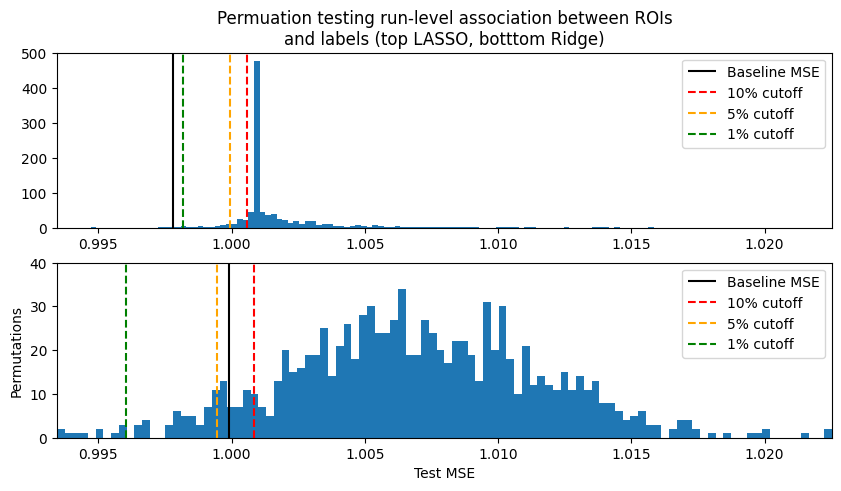

In [ ]:
# Histograms

plt.figure(figsize=(10, 5))
plt.subplot(2, 1, 1)
plt.hist(lasso, bins=100)
plt.vlines(lasso_baseline, ymin=0,
           ymax=500, colors='black', label='Baseline MSE')
plt.vlines(lasso_q10, ymin=0,
           ymax=500, colors='red', label='10% cutoff', linestyles='--')
plt.vlines(lasso_q05, ymin=0,
           ymax=500, colors='orange', label='5% cutoff', linestyles='--')
plt.vlines(lasso_q01, ymin=0,
           ymax=500, colors='green', label='1% cutoff', linestyles='--')
plt.xlim([xmin, xmax])
plt.ylim([0, 500])
plt.title(
    'Permuation testing run-level association between ROIs\nand labels (top LASSO, botttom Ridge)')
plt.legend()
plt.plot()

plt.subplot(2, 1, 2)
plt.hist(ridge, 100)
plt.vlines(ridge_baseline, ymin=0,
           ymax=40, colors='black', label='Baseline MSE')
plt.vlines(ridge_q10, ymin=0,
           ymax=40, colors='red', label='10% cutoff', linestyles='--')
plt.vlines(ridge_q05, ymin=0,
           ymax=40, colors='orange', label='5% cutoff', linestyles='--')
plt.vlines(ridge_q01, ymin=0,
           ymax=40, colors='green', label='1% cutoff', linestyles='--')
plt.xlim([xmin, xmax])
plt.ylim([0, 40])
plt.ylabel('Permutations')
plt.xlabel('Test MSE')
plt.legend()
plt.plot()

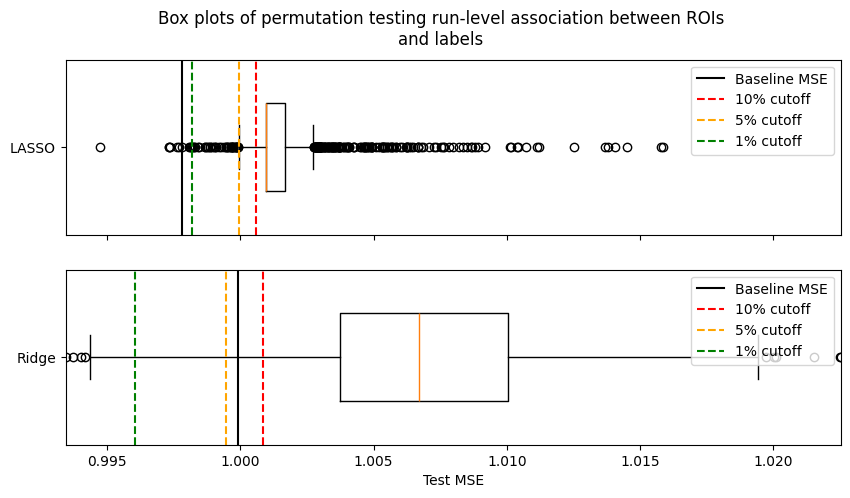

In [36]:
# Boxplots

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(10, 5))
fig.suptitle(
    'Box plots of permutation testing run-level association between ROIs\nand labels'
)

ax1.boxplot(lasso, vert=False, widths=0.5)
ax1.axvline(lasso_baseline, color='black', label='Baseline MSE')
ax1.axvline(lasso_q10, color='red', linestyle='--', label='10% cutoff')
ax1.axvline(lasso_q05, color='orange', linestyle='--', label='5% cutoff')
ax1.axvline(lasso_q01, color='green', linestyle='--', label='1% cutoff')
ax1.set_yticks([1])
ax1.set_yticklabels(['LASSO'])
ax1.legend(loc='upper right')

ax2.boxplot(ridge, vert=False, widths=0.5)
ax2.axvline(ridge_baseline, color='black', label='Baseline MSE')
ax2.axvline(ridge_q10, color='red', linestyle='--', label='10% cutoff')
ax2.axvline(ridge_q05, color='orange', linestyle='--', label='5% cutoff')
ax2.axvline(ridge_q01, color='green', linestyle='--', label='1% cutoff')
ax2.set_yticks([1])
ax2.set_yticklabels(['Ridge'])
ax2.set_xlabel('Test MSE')
ax2.legend(loc='upper right')

ax2.set_xlim(xmin, xmax)

plt.show()

# Multi-task ElasticNet models